CNNs (Convolutions → CNN Classifier)

What we cover here:
1) Convolution math (naive conv2d)
2) padding/stride shapes
3) CNN training in PyTorch
4) Feature map visualization

## Setup

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## 1) Naive 2D convolution (single channel)

In [2]:
def conv2d_naive_single_channel(x: np.ndarray, k: np.ndarray, stride: int = 1, padding: int = 0) -> np.ndarray:
    assert x.ndim == 2 and k.ndim == 2
    H, W = x.shape
    kH, kW = k.shape

    xpad = np.pad(x, ((padding, padding), (padding, padding)), mode="constant") if padding > 0 else x
    H2, W2 = xpad.shape
    outH = (H2 - kH) // stride + 1
    outW = (W2 - kW) // stride + 1
    out = np.zeros((outH, outW), dtype=np.float32)

    for i in range(outH):
        for j in range(outW):
            hs = i * stride
            ws = j * stride
            patch = xpad[hs:hs+kH, ws:ws+kW]
            out[i, j] = np.sum(patch * k)

    return out

x = np.arange(1, 1+5*5, dtype=np.float32).reshape(5,5)
k = np.array([[1,0,-1],[1,0,-1],[1,0,-1]], dtype=np.float32)
y = conv2d_naive_single_channel(x, k, stride=1, padding=0)
print("y shape:", y.shape)
print(y)


y shape: (3, 3)
[[-6. -6. -6.]
 [-6. -6. -6.]
 [-6. -6. -6.]]


### Compare with PyTorch conv2d

In [3]:
xt = torch.tensor(x).unsqueeze(0).unsqueeze(0)  # (1,1,5,5)
wt = torch.tensor(k).unsqueeze(0).unsqueeze(0)  # (1,1,3,3)
yt = F.conv2d(xt, wt, bias=None, stride=1, padding=0).squeeze().cpu().numpy()

print("max abs diff:", np.max(np.abs(y - yt)))


max abs diff: 0.0


## 2) Stride/padding shapes

In [4]:
x = np.random.default_rng(0).normal(size=(8,8)).astype(np.float32)
k = np.ones((3,3), dtype=np.float32)
for padding in [0,1,2]:
    for stride in [1,2]:
        y = conv2d_naive_single_channel(x, k, stride=stride, padding=padding)
        print(f"padding={padding} stride={stride} => out={y.shape}")


padding=0 stride=1 => out=(6, 6)
padding=0 stride=2 => out=(3, 3)
padding=1 stride=1 => out=(8, 8)
padding=1 stride=2 => out=(4, 4)
padding=2 stride=1 => out=(10, 10)
padding=2 stride=2 => out=(5, 5)


## 3) Synthetic 28×28 image dataset (4 classes)

Classes:
0 vertical, 1 horizontal, 2 diagonal, 3 plus. Add noise + random shifts.


X: (2000, 1, 28, 28) y: (2000,) counts: [484 507 501 508]


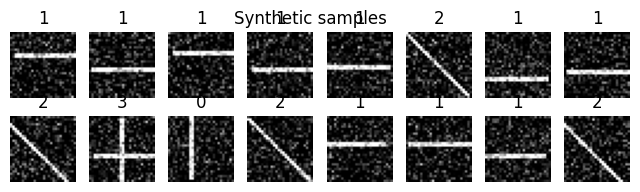

In [5]:
def draw_vertical(img, x): img[:, x:x+2] = 1.0
def draw_horizontal(img, y): img[y:y+2, :] = 1.0
def draw_diagonal(img):
    for i in range(img.shape[0]):
        j = i
        if j < img.shape[1]:
            img[i, j] = 1.0
            if j+1 < img.shape[1]: img[i, j+1] = 1.0
def draw_plus(img, cx, cy):
    img[cy:cy+2, :] = 1.0
    img[:, cx:cx+2] = 1.0

def jitter_shift(img, dx, dy):
    H, W = img.shape
    out = np.zeros_like(img)
    xs = max(0, dx); xe = min(W, W+dx)
    ys = max(0, dy); ye = min(H, H+dy)
    out[ys:ye, xs:xe] = img[ys-dy:ye-dy, xs-dx:xe-dx]
    return out

def make_synthetic_images(n: int = 4000, seed: int = 0, noise: float = 0.2):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 1, 28, 28), dtype=np.float32)
    y = np.zeros((n,), dtype=np.int64)

    for i in range(n):
        cls = int(rng.integers(0, 4))
        img = np.zeros((28, 28), dtype=np.float32)

        if cls == 0:
            draw_vertical(img, int(rng.integers(8, 20)))
        elif cls == 1:
            draw_horizontal(img, int(rng.integers(8, 20)))
        elif cls == 2:
            draw_diagonal(img)
        else:
            draw_plus(img, int(rng.integers(10, 18)), int(rng.integers(10, 18)))

        img = jitter_shift(img, int(rng.integers(-3, 4)), int(rng.integers(-3, 4)))
        img += rng.normal(scale=noise, size=img.shape).astype(np.float32)
        img = np.clip(img, 0.0, 1.0)

        X[i,0] = img
        y[i] = cls

    idx = rng.permutation(n)
    return X[idx], y[idx]

X, y = make_synthetic_images(n=2000, seed=1, noise=0.25)
print("X:", X.shape, "y:", y.shape, "counts:", np.bincount(y))

plt.figure(figsize=(8,2))
for i in range(16):
    plt.subplot(2,8,i+1)
    plt.imshow(X[i,0], cmap="gray")
    plt.axis("off")
    plt.title(int(y[i]))
plt.suptitle("Synthetic samples")
plt.show()


## 4) DataLoaders

In [6]:
def split_train_val(X, y, val_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    n = len(y)
    idx = rng.permutation(n)
    n_val = int(n*val_ratio)
    va = idx[:n_val]
    tr = idx[n_val:]
    return X[tr], y[tr], X[va], y[va]

Xtr, ytr, Xva, yva = split_train_val(X, y, val_ratio=0.2, seed=2)

class ImgDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

tr_dl = DataLoader(ImgDataset(Xtr, ytr), batch_size=128, shuffle=True)
va_dl = DataLoader(ImgDataset(Xva, yva), batch_size=256, shuffle=False)

xb, yb = next(iter(tr_dl))
print("batch:", xb.shape, yb.shape)


batch: torch.Size([128, 1, 28, 28]) torch.Size([128])


## 5) CNN model + training

epoch=01 tr_loss=1.3293 va_acc=0.659
epoch=02 tr_loss=1.0121 va_acc=0.948
epoch=03 tr_loss=0.4958 va_acc=0.943
epoch=04 tr_loss=0.2173 va_acc=0.974
epoch=05 tr_loss=0.1131 va_acc=0.978
epoch=06 tr_loss=0.0653 va_acc=0.989
epoch=07 tr_loss=0.0481 va_acc=0.995
epoch=08 tr_loss=0.0293 va_acc=1.000
epoch=09 tr_loss=0.0210 va_acc=1.000
epoch=10 tr_loss=0.0155 va_acc=1.000


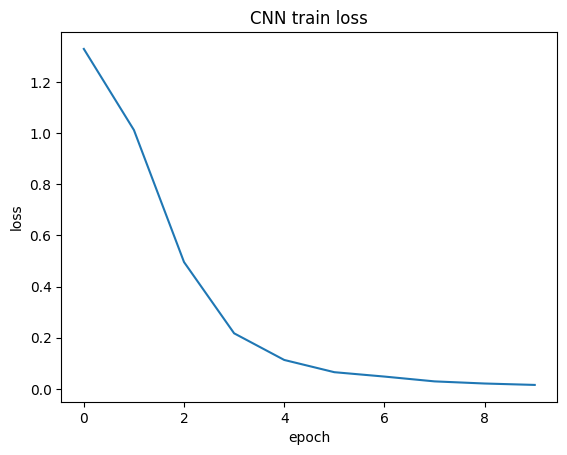

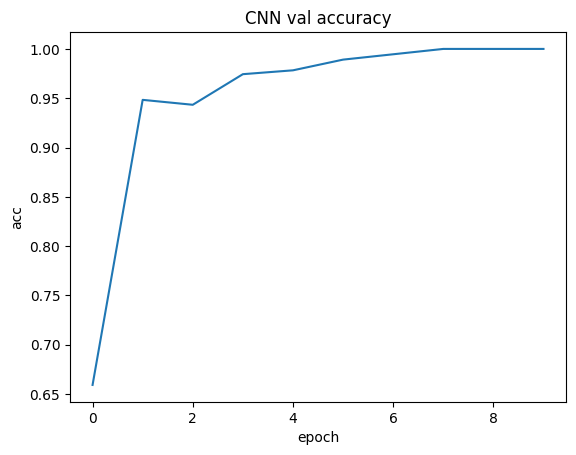

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 28 -> 28
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # 14 -> 14
        self.pool = nn.MaxPool2d(2)                   # /2
        self.fc = nn.Linear(32*7*7, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28 -> 14
        x = self.pool(F.relu(self.conv2(x)))  # 14 -> 7
        x = x.view(x.size(0), -1)
        return self.fc(x)

@torch.no_grad()
def accuracy_logits(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

def train_model(model, tr_dl, va_dl, epochs=10, lr=1e-3):
    model.to(device)
    opt = optim.AdamW(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"tr_loss": [], "va_acc": []}

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0; n = 0
        for xb, yb in tr_dl:
            xb = xb.to(device); yb = yb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)
        tr_loss = total / n

        model.eval()
        accs = []
        with torch.no_grad():
            for xb, yb in va_dl:
                xb = xb.to(device); yb = yb.to(device)
                logits = model(xb)
                accs.append(accuracy_logits(logits, yb))
        va_acc = float(np.mean(accs))

        hist["tr_loss"].append(tr_loss)
        hist["va_acc"].append(va_acc)
        print(f"epoch={ep:02d} tr_loss={tr_loss:.4f} va_acc={va_acc:.3f}")
    return hist

cnn = SimpleCNN(n_classes=4)
hist_cnn = train_model(cnn, tr_dl, va_dl, epochs=10, lr=1e-3)

plt.figure(); plt.plot(hist_cnn["tr_loss"]); plt.title("CNN train loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()
plt.figure(); plt.plot(hist_cnn["va_acc"]); plt.title("CNN val accuracy"); plt.xlabel("epoch"); plt.ylabel("acc"); plt.show()


## 6) Inspect predictions + conv feature maps

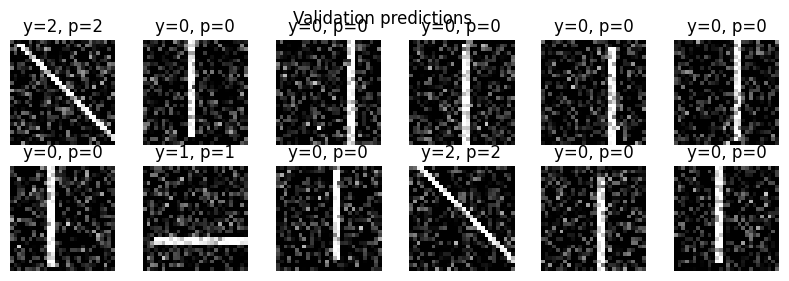

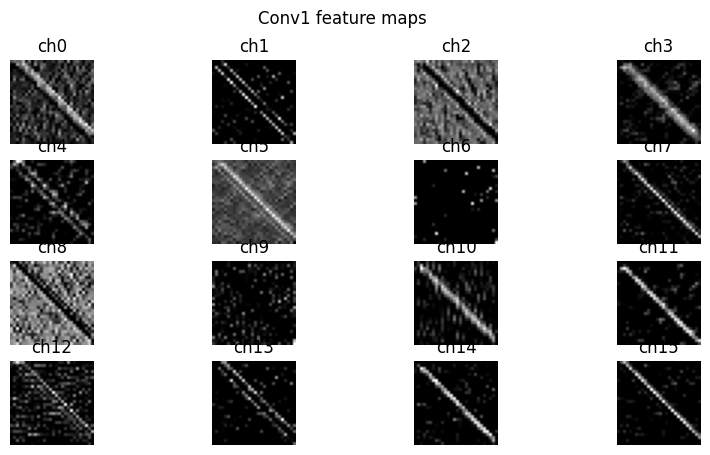

In [8]:
cnn.eval()
xb, yb = next(iter(va_dl))
xb = xb.to(device)
with torch.no_grad():
    logits = cnn(xb)
    preds = logits.argmax(dim=1).cpu().numpy()

xb_cpu = xb.cpu().numpy()

plt.figure(figsize=(10,3))
for i in range(12):
    plt.subplot(2,6,i+1)
    plt.imshow(xb_cpu[i,0], cmap="gray")
    plt.axis("off")
    plt.title(f"y={int(yb[i])}, p={int(preds[i])}")
plt.suptitle("Validation predictions")
plt.show()

with torch.no_grad():
    fmap = F.relu(cnn.conv1(xb[:1]))  # (1,16,28,28)
fmap = fmap.cpu().numpy()[0]

plt.figure(figsize=(10,5))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(fmap[i], cmap="gray")
    plt.axis('off')
    plt.title(f"ch{i}")
plt.suptitle("Conv1 feature maps")
plt.show()


## 7) CNN vs MLP baseline (same task)

MLPs don’t share weights across space → often weaker generalization on images.


epoch=01 tr_loss=1.1126 va_acc=0.812
epoch=02 tr_loss=0.5438 va_acc=0.946
epoch=03 tr_loss=0.2633 va_acc=0.962
epoch=04 tr_loss=0.1408 va_acc=0.986
epoch=05 tr_loss=0.0780 va_acc=0.989
epoch=06 tr_loss=0.0520 va_acc=0.993
epoch=07 tr_loss=0.0347 va_acc=0.997
epoch=08 tr_loss=0.0250 va_acc=0.995
epoch=09 tr_loss=0.0197 va_acc=0.997
epoch=10 tr_loss=0.0156 va_acc=0.993


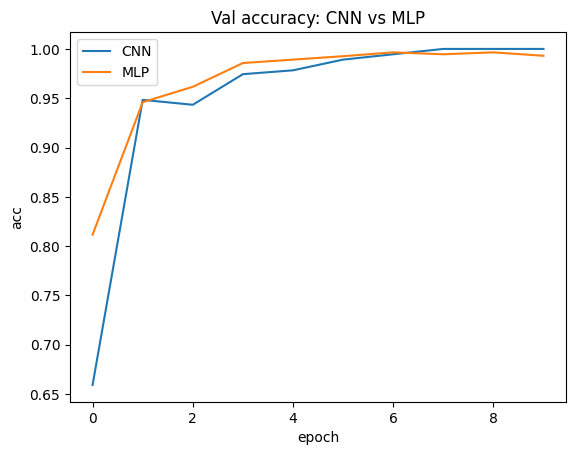

In [9]:
class SimpleMLP(nn.Module):
    def __init__(self, n_classes=4, hidden=256):
        super().__init__()
        self.fc1 = nn.Linear(28*28, hidden)
        self.fc2 = nn.Linear(hidden, n_classes)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

mlp = SimpleMLP(n_classes=4, hidden=256)
hist_mlp = train_model(mlp, tr_dl, va_dl, epochs=10, lr=1e-3)

plt.figure()
plt.plot(hist_cnn["va_acc"], label="CNN")
plt.plot(hist_mlp["va_acc"], label="MLP")
plt.title("Val accuracy: CNN vs MLP")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.show()
